# 부스팅(Boosting)
- 기본적으로는 랜덤 포래스트와 유사한다.
- 다른 점은 각 트리들이 던지는 답의 오차들을 보정할 수 있도록 오차 함수가 존재한다.
- 이를 통해 성능을 끌어 올린다.
- 너어어어어어어어어어어어어어어무 오래걸려요.ㅠㅠ(차라리 딥러닝을 쓰고 말지.ㅠㅠㅠㅠ)

### 라이브러리 설치
- pip install xgboost
- pip install lightgbm


In [8]:
# 기본

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 경고 뜨지 않게 설정
import warnings
warnings.filterwarnings('ignore')

# 그래프 설정
sns.set()

# 그래프 기본 설정
plt.rcParams['font.family'] = 'Malgun Gothic'
# plt.rcParams['font.family'] = 'AppleGothic'
plt.rcParams['figure.figsize'] = 12, 6
plt.rcParams['font.size'] = 14
plt.rcParams['axes.unicode_minus'] = False

# 데이터 전처리 알고리즘
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

# 학습용과 검증용으로 나누는 함수
from sklearn.model_selection import train_test_split

# 교차 검증
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import cross_validate
from sklearn.model_selection import KFold
from sklearn.model_selection import StratifiedKFold

# 평가함수
# 분류용
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import roc_auc_score

# 회귀용
from sklearn.metrics import r2_score
from sklearn.metrics import mean_squared_error

# 모델의 최적의 하이퍼 파라미터를 찾기 위한 도구
from sklearn.model_selection import GridSearchCV

# 머신러닝 알고리즘 - 분류
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import GradientBoostingClassifier
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier

# 머신러닝 알고리즘 - 회귀
from sklearn.neighbors import KNeighborsRegressor
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Ridge
from sklearn.linear_model import Lasso
from sklearn.linear_model import ElasticNet
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import AdaBoostRegressor
from sklearn.ensemble import GradientBoostingRegressor
from lightgbm import LGBMRegressor
from xgboost import XGBRegressor

import pickle

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


### 분류

In [3]:
# 학습이 완료된 모델을 저장할 파일 이름
best_model_path = '/content/drive/MyDrive/model/best_model_pca20.dat'
# 교차검증 횟수
cv_count = 10
# 교차 검증
kfold = KFold(n_splits=cv_count, shuffle=True, random_state=1)
# 평가 결과를 담을 리스트
# 필요하다면 다른 것도 만들어주세요
f1_score_list = []
# 학습 모델 이름
model_name_list = []

In [4]:
# 데이터 준비
train_df = pd.read_parquet('/content/drive/MyDrive/pca_result20.parquet')
test_df = pd.read_parquet('/content/drive/MyDrive/test_pca.parquet')
target_df = pd.read_csv('/content/drive/MyDrive/Segment.csv')

display(train_df.columns)
display(test_df.columns)

Index(['PC1', 'PC2', 'PC3', 'PC4', 'PC5', 'PC6', 'PC7', 'PC8', 'PC9', 'PC10',
       'PC11', 'PC12', 'PC13', 'PC14', 'PC15', 'PC16', 'PC17', 'PC18', 'PC19',
       'PC20'],
      dtype='object')

Index(['p1', 'p2', 'p3', 'p4', 'p5', 'p6', 'p7', 'p8', 'p9', 'p10', 'p11',
       'p12', 'p13', 'p14', 'p15', 'p16', 'p17', 'p18', 'p19', 'p20'],
      dtype='object')

In [5]:
test_df.columns = train_df.columns

In [6]:
display(train_df.columns)
display(test_df.columns)

Index(['PC1', 'PC2', 'PC3', 'PC4', 'PC5', 'PC6', 'PC7', 'PC8', 'PC9', 'PC10',
       'PC11', 'PC12', 'PC13', 'PC14', 'PC15', 'PC16', 'PC17', 'PC18', 'PC19',
       'PC20'],
      dtype='object')

Index(['PC1', 'PC2', 'PC3', 'PC4', 'PC5', 'PC6', 'PC7', 'PC8', 'PC9', 'PC10',
       'PC11', 'PC12', 'PC13', 'PC14', 'PC15', 'PC16', 'PC17', 'PC18', 'PC19',
       'PC20'],
      dtype='object')

In [9]:
# 데이터 프레임을 합친다.
all_df = pd.concat([train_df, test_df])
all_df.reset_index(inplace=True, drop=True)
all_df

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,PC11,PC12,PC13,PC14,PC15,PC16,PC17,PC18,PC19,PC20
0,-2243.552932,73177.822751,-23307.067101,7561.747681,-3243.689945,4528.594709,-4408.328899,8369.204848,-6309.014637,1232.178489,-1801.699299,-1158.544592,8543.219158,-7222.996149,2033.216210,3042.690491,-883.032259,7041.455366,-670.054710,1078.355414
1,-4123.593576,-18596.799844,-5281.553927,552.003969,2047.728561,2851.121294,-2005.535562,3877.903213,-889.924578,3031.998141,4444.944146,4019.276075,81.980862,3770.449219,-2605.992565,-3572.373986,1026.829959,673.134529,657.221494,1475.141169
2,93844.494983,123215.256247,-21110.839099,-7111.076140,-5582.733394,13547.760968,-1048.762695,9425.227218,1943.737286,-143.578502,-3836.158979,-4427.512129,7598.925399,-1826.845399,2988.844132,2877.510221,-2319.200651,-747.349425,-2800.120607,1230.518419
3,10648.448210,115700.176919,-21742.094578,11510.390683,-7770.532197,-7559.367414,-5333.651779,13026.736618,-76.952366,259.298026,9074.732502,-2156.688572,9575.604881,-5849.296710,1389.349113,2832.593697,-483.344559,5666.289330,-71.778407,949.210987
4,-76132.442560,-2534.422667,-1881.492818,724.219681,-55.011442,-2366.802627,-931.083210,71.543289,-16.547835,-290.180409,-874.771716,-257.463975,-733.477818,175.139486,33.954902,397.133624,183.348897,-279.655389,-284.008616,-2322.540834
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2999995,-75126.065178,-3705.200669,-3607.179085,706.459161,88.174555,-1576.755865,-1673.193124,66.734119,-311.373335,-693.622302,-303.601312,134.738903,-1061.311309,712.393919,-111.395017,115.492271,108.838629,-99.179137,52.185986,25.174936
2999996,-69393.140779,-2960.239513,-1778.824780,-236.728841,-975.862257,-3279.293100,-1335.075257,1572.949223,733.136011,-850.853958,442.423456,-101.670020,725.816597,760.382533,582.392682,871.562343,-175.810487,1104.853566,-301.709955,-972.853643
2999997,-75112.821137,-3689.619019,-3601.622699,707.283479,73.604402,-1557.581432,-1663.292202,80.980237,-310.201036,-691.082195,-243.946034,55.711326,-967.948405,675.508403,-100.595249,138.351910,107.394475,-24.579676,64.067690,53.626987
2999998,429765.434664,-147776.679157,-45333.927657,-79709.429111,-51300.598712,-19337.740260,4039.117738,2184.738332,42456.455292,14162.848902,9130.737374,-30639.249248,-12570.518026,-12338.005664,52.894266,-1217.003939,16497.104539,-3638.910629,1245.666856,1028.243296


In [10]:
# 입력과 결과로 나눈다.
X = train_df
y = target_df['Segment']

In [25]:
train_df

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,PC11,PC12,PC13,PC14,PC15,PC16,PC17,PC18,PC19,PC20
0,-2243.552932,73177.822751,-23307.067101,7561.747681,-3243.689945,4528.594709,-4408.328899,8369.204848,-6309.014637,1232.178489,-1801.699299,-1158.544592,8543.219158,-7222.996149,2033.216210,3042.690491,-883.032259,7041.455366,-670.054710,1078.355414
1,-4123.593576,-18596.799844,-5281.553927,552.003969,2047.728561,2851.121294,-2005.535562,3877.903213,-889.924578,3031.998141,4444.944146,4019.276075,81.980862,3770.449219,-2605.992565,-3572.373986,1026.829959,673.134529,657.221494,1475.141169
2,93844.494983,123215.256247,-21110.839099,-7111.076140,-5582.733394,13547.760968,-1048.762695,9425.227218,1943.737286,-143.578502,-3836.158979,-4427.512129,7598.925399,-1826.845399,2988.844132,2877.510221,-2319.200651,-747.349425,-2800.120607,1230.518419
3,10648.448210,115700.176919,-21742.094578,11510.390683,-7770.532197,-7559.367414,-5333.651779,13026.736618,-76.952366,259.298026,9074.732502,-2156.688572,9575.604881,-5849.296710,1389.349113,2832.593697,-483.344559,5666.289330,-71.778407,949.210987
4,-76132.442560,-2534.422667,-1881.492818,724.219681,-55.011442,-2366.802627,-931.083210,71.543289,-16.547835,-290.180409,-874.771716,-257.463975,-733.477818,175.139486,33.954902,397.133624,183.348897,-279.655389,-284.008616,-2322.540834
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2399995,-70708.144660,-4606.543015,2805.802812,-7312.121123,-3526.939822,-4965.947915,220.135110,1057.678514,2360.636905,1934.651583,-163.516889,708.018807,214.886523,5754.416596,702.458456,955.251106,-14.643096,-632.996631,-775.194684,-1093.950885
2399996,140275.356531,814.052456,-29512.108763,23504.905496,-9175.280458,5675.125390,16409.620661,2465.542079,-4928.311456,2604.849953,-3077.700232,6591.170072,10879.633153,-2992.836249,426.796670,318.107475,-977.313742,-6006.581767,245.148050,-1467.533940
2399997,17590.595794,3334.474385,5996.492941,645.269906,-4197.372201,1762.693539,-60.440878,2115.391055,-919.578187,2820.212873,-958.204721,525.676414,-380.947312,6726.808438,1658.164988,1024.548829,684.830802,1682.248551,-405.046697,302.598915
2399998,-75089.653850,-3665.731945,-3620.020117,709.662982,42.502434,-1556.732214,-1652.830373,84.509015,-302.824774,-692.984228,-136.638593,-56.361795,-719.324236,542.313778,-101.509804,137.693934,68.816194,-250.279003,3.779371,-234.113636


In [12]:
scalerX = StandardScaler()
scalerX.fit(X)

StandardScaler()

In [13]:
# 표준화
X2 = scalerX.transform(X)
X2

array([[-2.23294525e-02,  2.21219926e+00, -1.28889950e+00, ...,
         3.00673497e+00, -3.18427020e-01,  5.67277126e-01],
       [-4.10409693e-02, -5.62189818e-01, -2.92074168e-01, ...,
         2.87431649e-01,  3.12328350e-01,  7.76009312e-01],
       [ 9.34007915e-01,  3.72485390e+00, -1.16744633e+00, ...,
        -3.19121763e-01, -1.33068845e+00,  6.47323640e-01],
       ...,
       [ 1.75074262e-01,  1.00802695e-01,  3.31610869e-01, ...,
         7.18328141e-01, -1.92488480e-01,  1.59184477e-01],
       [-7.47346246e-01, -1.10816764e-01, -2.00190016e-01, ...,
        -1.06870326e-01,  1.79605312e-03, -1.23157272e-01],
       [-3.56184976e-01,  1.31069930e-01,  4.41655075e-01, ...,
         9.47784744e-02, -3.12639587e-01,  2.36786138e-02]])

In [14]:
train_X = X2
train_y = y

In [15]:
le = LabelEncoder()
train_y = le.fit_transform(train_y)

In [16]:
from sklearn.model_selection import train_test_split

train_X_sub, test_X, train_y_sub, test_y = train_test_split(train_X, train_y, test_size=0.2, random_state=42)

### 기본 모델 사용하기

In [19]:
# LGBM
lgbm_basic_model = LGBMClassifier(verbose=-1)
# 교차 검증을 수행한다
r1 = cross_val_score(lgbm_basic_model, train_X_sub, train_y_sub, scoring='f1_micro', cv=kfold)
# 평가 결과를 담아준다.
f1_score_list.append(r1.mean())
# 학습 모델 이름을 담아준다.
model_name_list.append("LGBM Basic")

In [18]:
# XGBoost 모델 생성 (verbosity=0: 출력 최소화)
xgboost_basic_model = XGBClassifier(tree_method='gpu_hist', predictor='gpu_predictor',
                       n_jobs=-1, verbosity=0, use_label_encoder=False)

# kfold는 미리 정의된 KFold 객체라고 가정
r1 = cross_val_score(xgboost_basic_model, train_X_sub, train_y_sub, scoring='f1_micro', cv=kfold)

# 평가 결과를 담아준다.
f1_score_list.append(r1.mean())

# 학습 모델 이름을 담아준다.
model_name_list.append("XGBoost Basic")

| 클래스 | 샘플 수    | 기본 가중치(역수) | 완화된 가중치(로그) | 추천 가중치 (예시) |
|--------|------------|-------------------|---------------------|--------------------|
| 4      | 1,922,052  | 0.25              | 0.22                | 1                  |
| 3      | 349,242    | 1.37              | 0.95                | 1.5                |
| 2      | 127,590    | 3.76              | 1.5                 | 4                  |
| 0      | 972        | 493.9             | 6.2                 | 50                 |
| 1      | 144        | 3330.5            | 7.8                 | 50                 |


In [20]:
### 가중치 줘보기
class_weights = {0: 40., 1: 155, 2: 4, 3: 1.5, 4: 1}

In [21]:
# LGBM 가중치 모델 정의
lgbm_weighted_model = LGBMClassifier(device='gpu', class_weight=class_weights, verbose=-1)

# KFold 설정
kfold = KFold(n_splits=5, shuffle=True, random_state=1)

# 교차검증 수행
f1_scores = cross_val_score(lgbm_weighted_model, train_X_sub, train_y_sub,
                            scoring='f1_weighted', cv=kfold)

# 평균 F1 점수를 리스트에 저장
f1_score_list.append(f1_scores.mean())

# 모델 이름 저장
model_name_list.append("LGBM Weighted")

In [23]:
# XGBoost 가중치 모델 정의
xgboost_weighted_model = XGBClassifier(tree_method='gpu_hist', predictor='gpu_predictor',
                                       n_jobs=-1, verbosity=0, use_label_encoder=False)

# Stratified K-Fold 설정
kfold = StratifiedKFold(n_splits=10, shuffle=True, random_state=1)

# 교차검증 F1 점수 저장용 리스트
f1_scores = []

# 각 fold에서 학습 및 평가
for fold, (train_idx, val_idx) in enumerate(kfold.split(train_X_sub, train_y_sub)):
    X_tr, X_val = train_X_sub[train_idx], train_X_sub[val_idx]
    y_tr, y_val = train_y_sub[train_idx], train_y_sub[val_idx]

    # 클래스별 가중치 적용
    sample_weights = np.array([class_weights[label] for label in y_tr])

    # 모델 학습
    xgboost_weighted_model.fit(X_tr, y_tr, sample_weight=sample_weights)

    # 예측 및 평가
    preds = xgboost_weighted_model.predict(X_val)
    f1 = f1_score(y_val, preds, average='weighted')
    f1_scores.append(f1)

    # 개별 Fold 출력 (선택사항)
    # print(f'Fold {fold+1} F1 Score: {f1:.4f}')

# 평균 F1 점수를 리스트에 저장
f1_score_list.append(np.mean(f1_scores))

# 모델 이름 저장
model_name_list.append("XGBoost Weighted")


### 모델 하이퍼 파라미터 튜닝

In [ ]:
10/0

In [24]:
# LGBM
params = {
    'n_estimators' : [50, 100, 150, 200, 250, 300],
    'learning_rate' : [0.0001, 0.001, 0.01, 0.1, 1, 0, 10, 100, 1000, 10000]
}

temp_model = LGBMClassifier(device='gpu', verbose=-1)
lgbm_grid_clf = GridSearchCV(temp_model, param_grid=params, scoring='f1_micro', cv=kfold)
lgbm_grid_clf.fit(train_X_sub, train_y_sub)

# 평가 결과를 담아준다.
f1_score_list.append(lgbm_grid_clf.best_score_)
# 학습 모델 이름을 담아준다.
model_name_list.append("LGBM Tuning")

KeyboardInterrupt: 

In [ ]:
# XGBoost
params = {
    'booster' : ['gbtree'],
    'n_estimators' : [50, 100, 150, 200, 250, 300],
    'learning_rate' : [0.0001, 0.001, 0.01, 0.1, 1, 0, 10, 100, 1000, 10000]
}

temp_model = XGBClassifier(tree_method='gpu_hist', predictor='gpu_predictor',
                       n_jobs=-1, verbosity=0, use_label_encoder=False)
xgboost_grid_clf = GridSearchCV(temp_model, param_grid=params, scoring='f1_micro', cv=kfold)
xgboost_grid_clf.fit(train_X_sub, train_y_sub)

# 평가 결과를 담아준다.
f1_score_list.append(xgboost_grid_clf.best_score_)
# 학습 모델 이름을 담아준다.
model_name_list.append("XGBoost Tuning")

In [26]:
d1 = {
    'f1 score' : f1_score_list
}
result_df = pd.DataFrame(d1, index=model_name_list)
result_df.sort_values(by='f1 score', ascending=False, inplace=True)
result_df

,f1 score
XGBoost Basic,0.873263
LGBM Basic,0.866654
XGBoost Weighted,0.863587
LGBM Weighted,0.860492


### 예측을 수행한다

In [27]:
# 최종 모델을 생성하고 전체 데이터를 학습 시킨다.
best_model = XGBClassifier(tree_method='gpu_hist', predictor='gpu_predictor',
                       n_jobs=-1, verbosity=0, use_label_encoder=False)

best_model.fit(train_X_sub, train_y_sub)
best_model

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              gamma=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=-1,
              num_parallel_tree=None, objective='multi:softprob', ...)

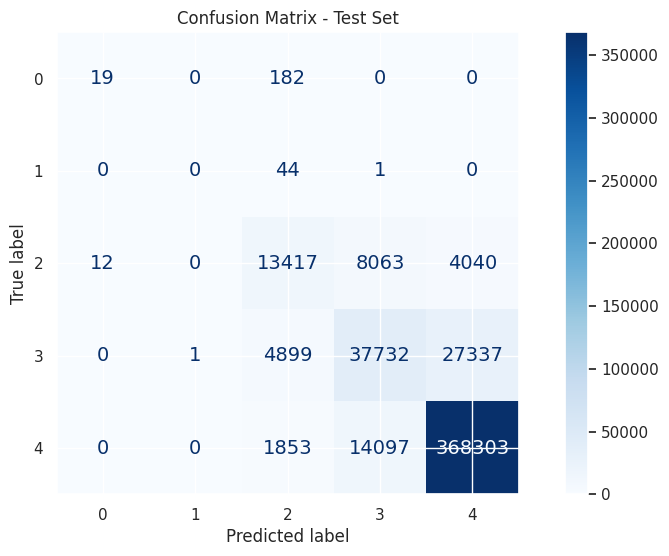

In [28]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# 1. 최종 예측
y_pred = best_model.predict(test_X)

# 2. 혼동 행렬 계산
cm = confusion_matrix(test_y, y_pred)

# 3. 시각화
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues', values_format='d')  # 'd'는 정수형 표시
plt.title("Confusion Matrix - Test Set")
plt.show()

In [29]:
# 학습 모델 등을 저장한다.
with open(best_model_path, 'wb') as fp :

    # 인코더들
    pickle.dump(le, fp)
    pickle.dump(best_model, fp)
    pickle.dump(scalerX, fp)

print('저장완료')

저장완료
